# 03 — Alignement par préférences (DPO)

Le fine-tuning apprend à **répondre**. L'alignement apprend à **préférer** : entre
deux réponses au même cas, celle qui ne sous-évalue pas l'urgence, ne retarde pas
la prise en charge, n'affirme pas de diagnostic, et respecte la langue imposée.

Tout dépend alors de ce que les deux réponses ont de différent — parce que le
modèle apprendra la différence qu'il trouve, pas celle qu'on avait en tête.

In [1]:
import json
from collections import Counter

import pandas as pd

from chsa_triage.config import PATHS

pd.set_option("display.max_colwidth", 120)


def lire(chemin):
    return json.loads(chemin.read_text(encoding="utf-8")) if chemin.exists() else None


dpo = lire(PATHS.reports / "training" / "dpo.json")
metadonnees = lire(PATHS.data_processed / "metadata.json")
paires = [
    json.loads(ligne) for ligne in (PATHS.data_processed / "dpo_train.jsonl").open(encoding="utf-8")
]
print(f"{len(paires)} paires de preference")

2400 paires de preference


## 1. Le piège de la longueur

Une première version de ce jeu opposait une bonne réponse de trois lignes à une
réponse rejetée évasive d'une demi-ligne :

| | texte |
|---|---|
| préférée | `Niveau de priorité : URGENCE_VITALE` + justification + recommandation (≈ 350 caractères) |
| rejetée | `Je ne suis pas sûr. Consultez un médecin si cela ne passe pas.` (≈ 60 caractères) |

La seule différence **systématique** entre les deux n'était pas le fond : c'était
la longueur. Le modèle a appris « plus long vaut mieux », et la conséquence a été
immédiate — il a cessé d'émettre son jeton de fin, produisant des réponses qui
couraient jusqu'à la limite de génération.

Le jeu livré impose donc le même format et une longueur comparable. Chaque défaut
est décliné en plusieurs longueurs, et l'on retient celle qui colle au plus près
de la réponse préférée.

In [2]:
equilibre = metadonnees["statistiques"]["dpo_equilibre_longueurs"]
print(f"longueur moyenne de la reponse preferee : {equilibre['chosen_moyenne']:.0f} caracteres")
print(f"longueur moyenne de la reponse rejetee  : {equilibre['rejected_moyenne']:.0f} caracteres")
print(
    f"part des paires ou la preferee est la plus longue : {equilibre['part_chosen_plus_long']:.1%}"
)
print()
print("Une part proche de 50 % signifie qu'aucun signal de longueur n'est exploitable.")

longueur moyenne de la reponse preferee : 354 caracteres
longueur moyenne de la reponse rejetee  : 345 caracteres
part des paires ou la preferee est la plus longue : 43.7%

Une part proche de 50 % signifie qu'aucun signal de longueur n'est exploitable.


## 2. Ce qu'on apprend au modèle à éviter

Quatre défauts, tous introduits **sans changer le format**. Le surclassement n'en
fait pas partie : la consigne système impose de surclasser au moindre doute, et
présenter une réponse trop prudente comme mauvais exemple apprendrait exactement
l'inverse.

In [3]:
repartition = Counter(paire["strategie"] for paire in paires)
pd.DataFrame(sorted(repartition.items()), columns=["defaut introduit", "paires"])

,defaut introduit,paires
0,diagnostic_affirme,627
1,recommandation_dangereuse,676
2,reponse_en_anglais,598
3,sous_triage,499


In [4]:
exemple = next(paire for paire in paires if paire["strategie"] == "sous_triage")
print("CAS")
print(exemple["user_turn"])
print()
print("REPONSE PREFEREE")
print(exemple["chosen"])
print()
print("REPONSE REJETEE")
print(exemple["rejected"])

CAS
Femme de 39 ans se présente pour malaise avec gonflement du visage après une piqûre d'insecte brutalement il y a un quart d'heure. On note urticaire généralisée et chute de la tension. Antécédents : asthme et allergie connue aux hyménoptères. Constantes : FC 82/min, TA 76/51 mmHg, FR 20/min, SpO2 99 %, T 36.8 °C, douleur 8/10, vigilance altérée.
Indique le niveau de triage et la conduite à tenir.

REPONSE PREFEREE
Niveau de priorité : URGENCE_VITALE
Justification : Atteinte cutanée, respiratoire et hémodynamique après exposition à un allergène : choc anaphylactique, dont le traitement ne souffre aucun délai.
Recommandation : Adrénaline intramusculaire immédiate, position allongée jambes surélevées, oxygénothérapie et appel du 15 (SAMU). Surveillance prolongée du fait du risque de réaction biphasique.

REPONSE REJETEE
Niveau de priorité : URGENCE_MODEREE
Justification : La description ne comporte pas d'élément suffisamment inquiétant pour justifier une prise en charge accélérée ; l'

Les deux réponses ont la même structure et une longueur voisine. La seule
différence est le **niveau annoncé** et la justification qui le minimise : c'est
exactement ce que l'alignement doit apprendre à écarter.

In [5]:
repartition_niveaux = Counter(paire["level"] for paire in paires)
print("Les cas graves sont sur-representes : le sous-triage d'une urgence vitale")
print("est la faute la plus couteuse.")
print()
for niveau, nombre in repartition_niveaux.most_common():
    print(f"  {niveau:24s} : {nombre}")

Les cas graves sont sur-representes : le sous-triage d'une urgence vitale
est la faute la plus couteuse.

  URGENCE_VITALE           : 1032
  URGENCE_MODEREE          : 869
  CONSULTATION_DIFFEREE    : 499


## 3. Trois choix de méthode qui protègent l'acquis du fine-tuning

**La référence est le modèle supervisé fusionné, pas le modèle de base.** On
charge le modèle SFT et on y greffe un *nouvel* adaptateur : la bibliothèque
utilise alors le modèle adaptateur désactivé comme référence, c'est-à-dire le
modèle SFT lui-même. Avec le modèle de base comme référence, l'alignement serait
libre de s'éloigner du format tout juste appris.

**`rpo_alpha` ajoute la perte supervisée sur la réponse préférée.** L'objectif DPO
seul n'optimise qu'un rapport de vraisemblances : il peut faire baisser la
probabilité des deux réponses pourvu que l'écart se creuse. Ce terme
supplémentaire maintient la réponse préférée à un niveau élevé.

**L'adaptateur ne touche pas à la tête de sortie.** Le fine-tuning s'en est déjà
chargé — c'est ce qui rend le modèle capable de s'arrêter, voir le carnet 02 — et
le modèle fusionné qui sert de base porte donc déjà une tête entraînée. Laisser la
tête hors de l'adaptateur le garde petit, et surtout **servable à chaud par
vLLM**, qui refuse les adaptateurs embarquant une matrice entraînée en entier.


In [6]:
if dpo:
    for cle, valeur in dpo["hyperparametres"].items():
        print(f"  {cle:24s} : {valeur}")

  modele_de_reference      : qwen3-1.7b-triage-sft-merged
  moteur                   : unsloth
  epochs                   : 1
  batch_size               : 2
  grad_accum               : 8
  lot_effectif             : 16
  learning_rate            : 5e-06
  beta                     : 0.1
  rpo_alpha                : 1.0
  lora_r                   : 16
  lora_alpha               : 32
  max_length               : 768
  max_steps                : -1
  graine                   : 42


## 4. Courbes d'alignement

Un **jeu de validation de préférences** est mis de côté. Sans lui, les seules
courbes disponibles seraient celles de l'entraînement, et rien ne distinguerait
un alignement qui généralise d'un alignement qui apprend par cœur.

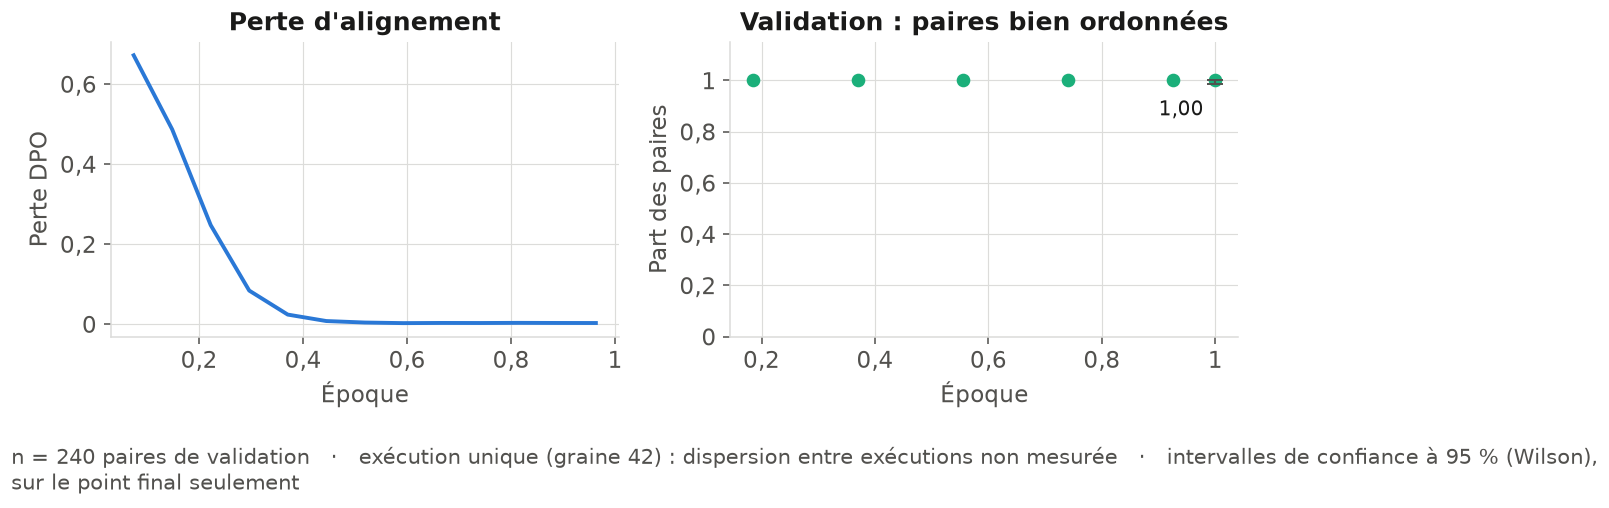

paires correctement ordonnees (validation) : 100.0%
marge de preference moyenne                : 9.26
duree                                      : 48 min
memoire GPU maximale                       : 9.8 Go


In [7]:
import matplotlib.pyplot as plt
from IPython.display import Image

from chsa_triage.reporting import figures

if dpo:
    figures.appliquer_style()
    chemin = figures.alignement_dpo(
        dpo["historique"],
        PATHS.figures / "04_alignement_dpo.png",
        paires=dpo["metriques"].get("paires_validation", 0),
    )
    plt.close("all")
    display(Image(str(chemin)))

    metriques = dpo["metriques"]
    print(f"paires correctement ordonnees (validation) : {metriques['eval_reward_accuracy']:.1%}")
    print(f"marge de preference moyenne                : {metriques['eval_reward_margin']:.2f}")
    print(f"duree                                      : {metriques['duree_s'] / 60:.0f} min")
    print(f"memoire GPU maximale                       : {metriques['memoire_gpu_max_go']:.1f} Go")

## 5. Effet de l'alignement, cas par cas

Deux cas où le comportement attendu diffère : une urgence qui se donne l'air
bénin, et une demande sans caractère médical.

In [8]:
from chsa_triage.config import MODEL
from chsa_triage.inference import TriageAgent

cas = [
    (
        "Femme de 71 ans, diabetique, « tres fatiguee » depuis deux heures avec une vague nausee "
        "et un essoufflement inhabituel. Elle insiste : aucune douleur. FC 112, TA 96/60, SpO2 93 %."
    ),
    "Homme de 62 ans venu faire renouveler son ordonnance. Aucun symptome.",
]

reponses = {}
for nom, base, adaptateur in [
    ("SFT", MODEL.base_model, PATHS.sft_adapter),
    ("SFT + DPO", str(PATHS.sft_merged), PATHS.dpo_adapter),
]:
    agent = TriageAgent(adapter_dir=adaptateur, base_model=base)
    reponses[nom] = agent.generate_batch(cas)
    del agent
    import torch

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

for index, description in enumerate(cas):
    print(description)
    for nom in reponses:
        reponse = reponses[nom][index]
        print(f"  [{nom:9s}] {reponse.level} — {reponse.text.splitlines()[-1][:110]}")
    print()

2026-09-17 10:38:00,527 | INFO    | inference | Chargement du modèle Qwen/Qwen3-1.7B-Base sur cuda (unsloth)


unsloth/__init__.py:1554: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0917 10:38:01.218000 41392 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0917 10:38:01.258000 41392 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


...

==((====))==  Unsloth 2026.9.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4060 Ti. Num GPUs = 1. Max memory: 15.996 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.12.1+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.8.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


2026-09-17 10:38:23,956 | INFO    | inference | Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-dpo


[inference|INFO]Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-dpo


Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Femme de 71 ans, diabetique, « tres fatiguee » depuis deux heures avec une vague nausee et un essoufflement inhabituel. Elle insiste : aucune douleur. FC 112, TA 96/60, SpO2 93 %.
  [SFT      ] URGENCE_MODEREE — Recommandation : Hydratation, recherche de cétones, ionogramme, adaptation du traitement et avis diabétologiqu
  [SFT + DPO] URGENCE_MODEREE — Recommandation : Hydratation, recherche de cétones, ionogramme, adaptation du traitement et avis diabétologiqu

Homme de 62 ans venu faire renouveler son ordonnance. Aucun symptome.
  [SFT      ] CONSULTATION_DIFFEREE — Recommandation : Orienter vers le médecin traitant ou le pharmacien pour une dispensation de dépannage, expliq
  [SFT + DPO] CONSULTATION_DIFFEREE — Recommandation : Orienter vers le médecin traitant pour une consultation dédiée, expliquer que les symptômes d



## Synthèse

- Le jeu de préférences est construit pour que la **seule** différence entre les
  deux réponses soit le fond : même format, longueur comparable, aucun
  surclassement présenté comme un contre-exemple.
- La référence de l'alignement est le modèle supervisé, ce qui interdit de
  défaire le format tout juste appris.
- Un jeu de validation de préférences permet de mesurer l'alignement sur des
  paires jamais vues — la mesure qui manquait.
- L'apport réel du DPO se juge sur le jeu clinique indépendant : c'est l'objet du
  carnet 04.